In [807]:
import numpy as np
import pandas as pd
#import umap
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq

#from muon import prot as pt
from sklearn import preprocessing
import os
from matplotlib.colors import LogNorm
import itertools
import sys
path0 = '../../'
sys.path.append(path0+'phenotyping/')
from collections import defaultdict
from tqdm import tqdm
import seaborn as sns
import pickle
input_dir = 'pre_processed_files/'
output_fig = '../figures'
def strip_extension(self):
    '''strip the file extension from a pd.Series of file names'''
    return self.apply(lambda x: os.path.splitext(x)[0])

from phenotyping_utils import generate_anndata_from_ark_analysis
# Add the method to the Pandas Series class
pd.Series.strip_extension = strip_extension
%matplotlib inline

In [808]:
reload =True
file_name = path0+'phenotyping/pixie/data/sc_protein_by_patient.h5ad'
if reload:
    adata = sc.read_h5ad(file_name)
else:
    base_dir = '../../'
    cell_table_path=base_dir+'segmentation/cell_table_Denoised/cell_table_size_normalized_cell_labels.csv'
    biosamples_path=base_dir+'IMC_data/ExtraDocs/processed_response.csv'
    
    adata = generate_anndata_from_ark_analysis(cell_table_path=cell_table_path,biosamples_path=biosamples_path)
    
core = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].copy()
resection = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)'] == 'RESECTION']

In [ ]:
a = {'Non-Responder':0,'pCR':1}
list(map(lambda x:a.get(x),adata.obs.Response))

In [150]:
adata.obs.new_Response.value_counts()

Non-Responder    1491581
pCR              1442832
enR               622447
Name: new_Response, dtype: int64

In [23]:
#neigh_all is a dictionary, containing the fov as key, and a dataframe of z-scores.The dataframe contains only the element in the fov
with open('neighbours_matrix.pkl', 'rb') as f:
    data = pickle.load(f)


Take only the core

In [159]:
labels_list = adata.obs.Pixie.unique()#these are all the cell types
labels_list2 = (core.obs.Pixie.value_counts()/core.obs.acquisition_ID.nunique()>20)#Filter out cell types that have few cells
labels_list2 = labels_list2[labels_list2].index.to_list()
def expand_df(tb,labels_list,labels_list2):
    '''
    Takes the dataframe tb, creates a dataframe full of zeros where it embeds tb into. The extracts only the columns and rows with labels in label_list2
    '''
    temp_matrix = pd.DataFrame(0,index = labels_list,columns=labels_list)
    sub_list = tb.index#label list
    #tb.replace([np.inf, -np.inf], np.nan, inplace=True) # convert inf to nan, next line everything is replaced with 0
    temp_matrix.loc[sub_list,sub_list]=tb
    temp_matrix = temp_matrix.loc[labels_list2,labels_list2]
    temp_values = temp_matrix.values
    return temp_values

X_enrichment = []
X_contact = []
ids = []
core_ids = set(core.obs.acquisition_ID)
for id,sub_dic in data.items():
    if id not in core_ids:
        continue
    tb_en = sub_dic['enrichment']
    tb_cont = sub_dic['interaction']
    X_enrichment +=[expand_df(tb_en,labels_list,labels_list2)]
    X_contact +=[expand_df(tb_cont,labels_list,labels_list2)]
    ids+=[id]
y = np.vectorize(dict(core.obs[['acquisition_ID','Response']].values).get)(ids)
X_enrichment = np.array(X_enrichment)
X_contact = np.array(X_contact)
ids = pd.DataFrame(ids,columns = ['acqusition_ID'])

In [323]:
ids['Leap_ID'] = ids.acqusition_ID.str[:7]

In [282]:
import netlsd
import umap
from sklearn.preprocessing import StandardScaler

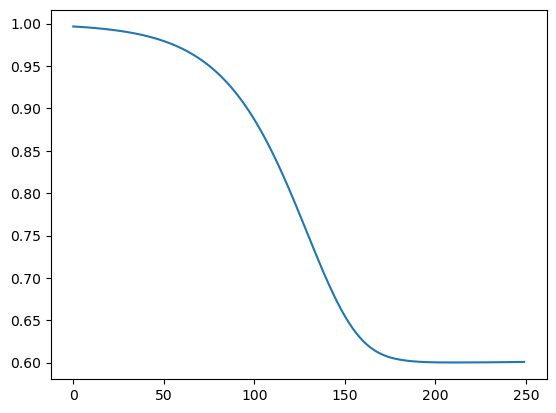

In [290]:
plt.plot(network_embedding[1])


In [325]:
import sklearn
pca = sklearn.decomposition.PCA(n_components=10)
contact_flattened = [x[np.tril_indices_from(x)]for x in X_contact]
contact_flattened = StandardScaler().fit_transform(contact_flattened)
network_embedding = pca.fit_transform(contact_flattened)
#np.cumsum(pca.explained_variance_ratio_)


In [326]:
#network_embedding = np.array([netlsd.heat(x)for x in X_contact])
#network_embedding = np.array([netlsd.heat(x)for x in X_contact])
reducer = umap.UMAP(n_neighbors=15)
network_embedding_scaled = network_embedding
#network_embedding_scaled = StandardScaler().fit_transform(network_embedding)
mapper = reducer.fit(network_embedding_scaled[:,:20])


<Axes: >

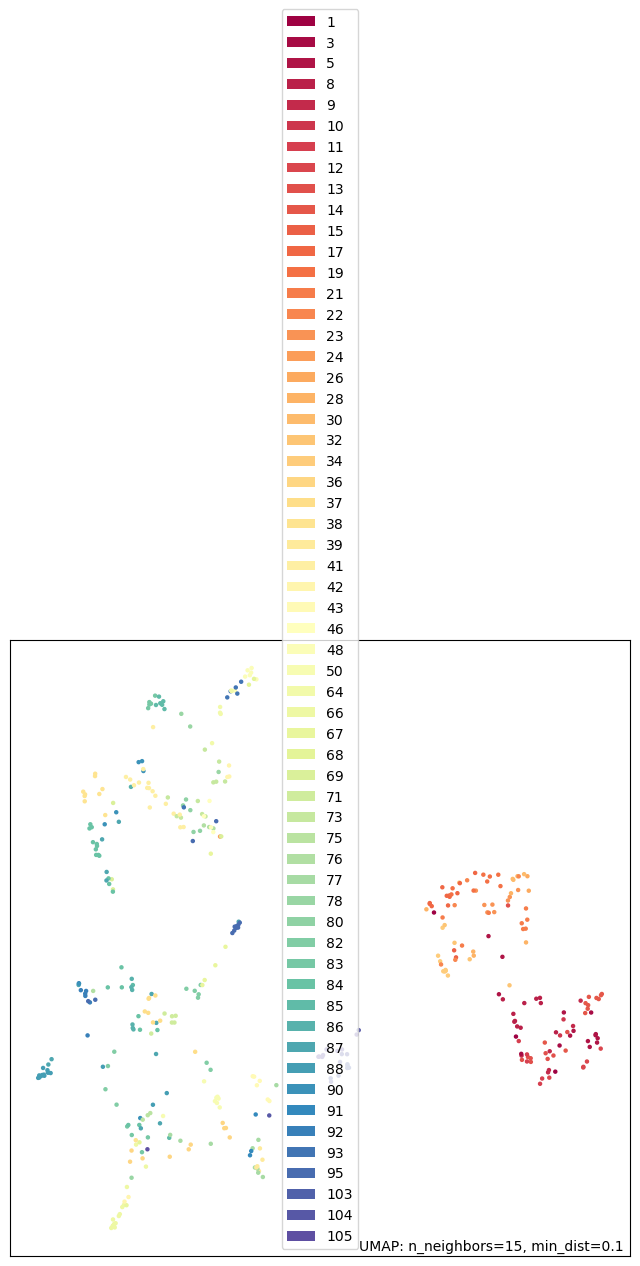

In [327]:
import umap.plot
umap.plot.points(mapper,labels=  ids.Leap_ID.str[-3:].astype(int))

<Axes: >

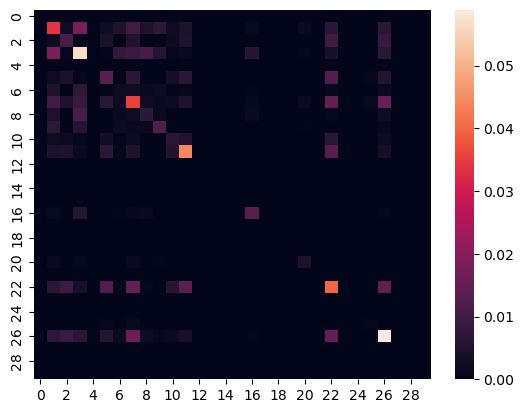

In [295]:
sns.heatmap(X_contact[4])


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


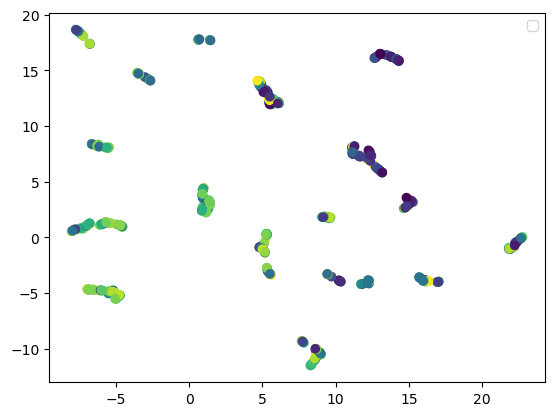

In [122]:
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c = ids.Leap_ID.str[-3:].astype(int))
plt.legend()

-4.40297225361002 4.40297225361002
-6.294031109385479 6.294031109385479


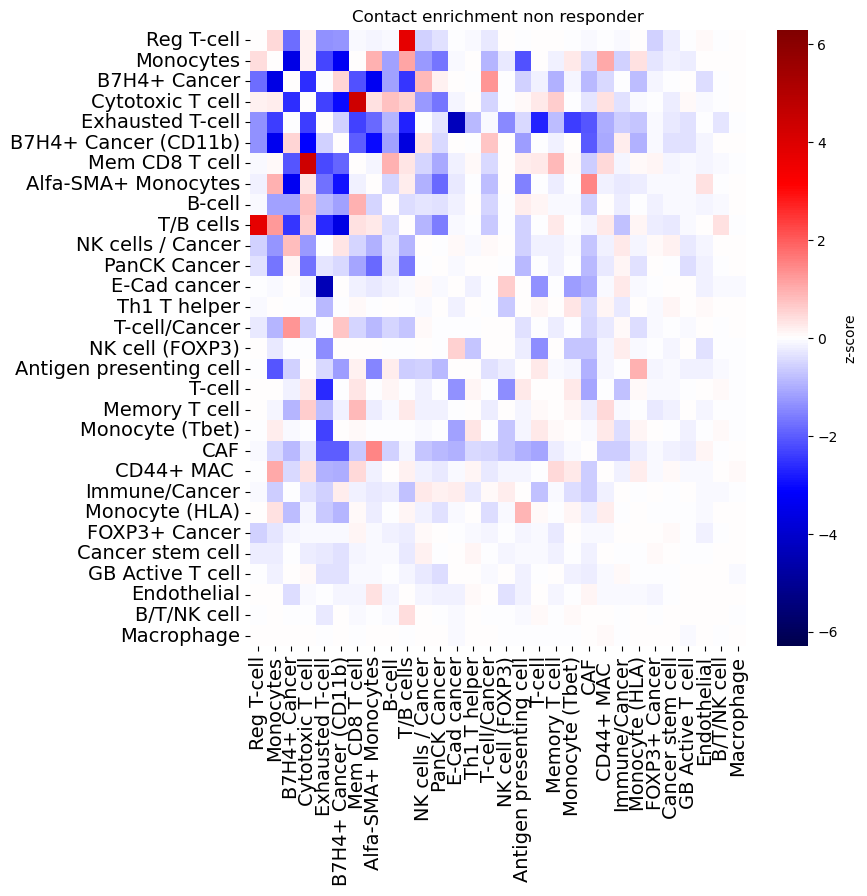

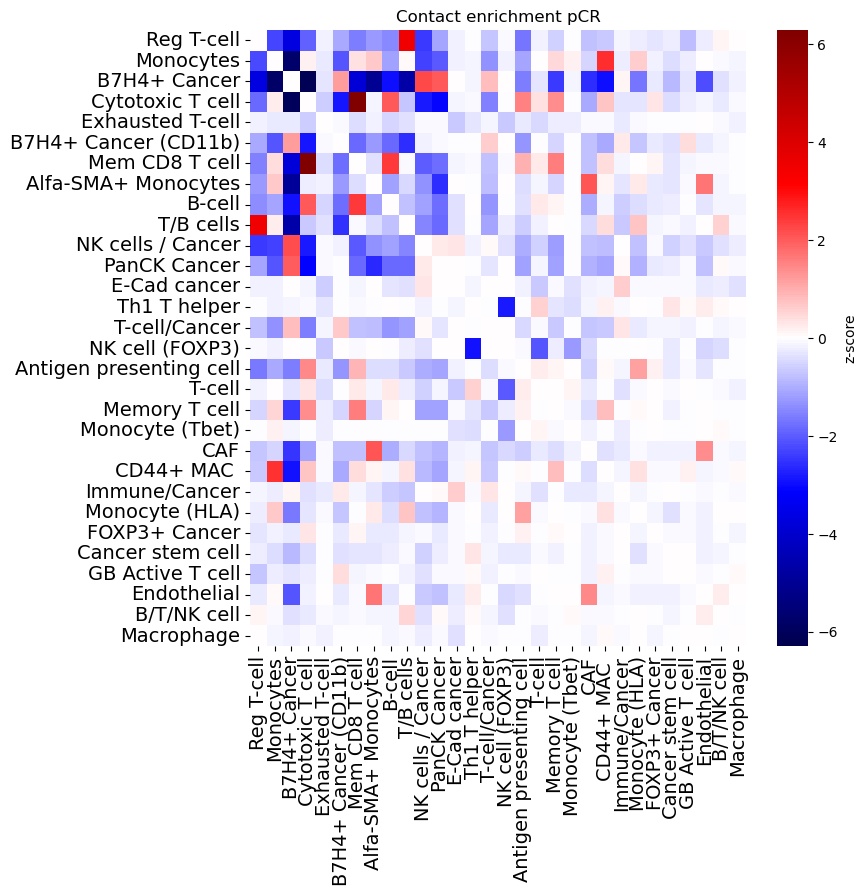

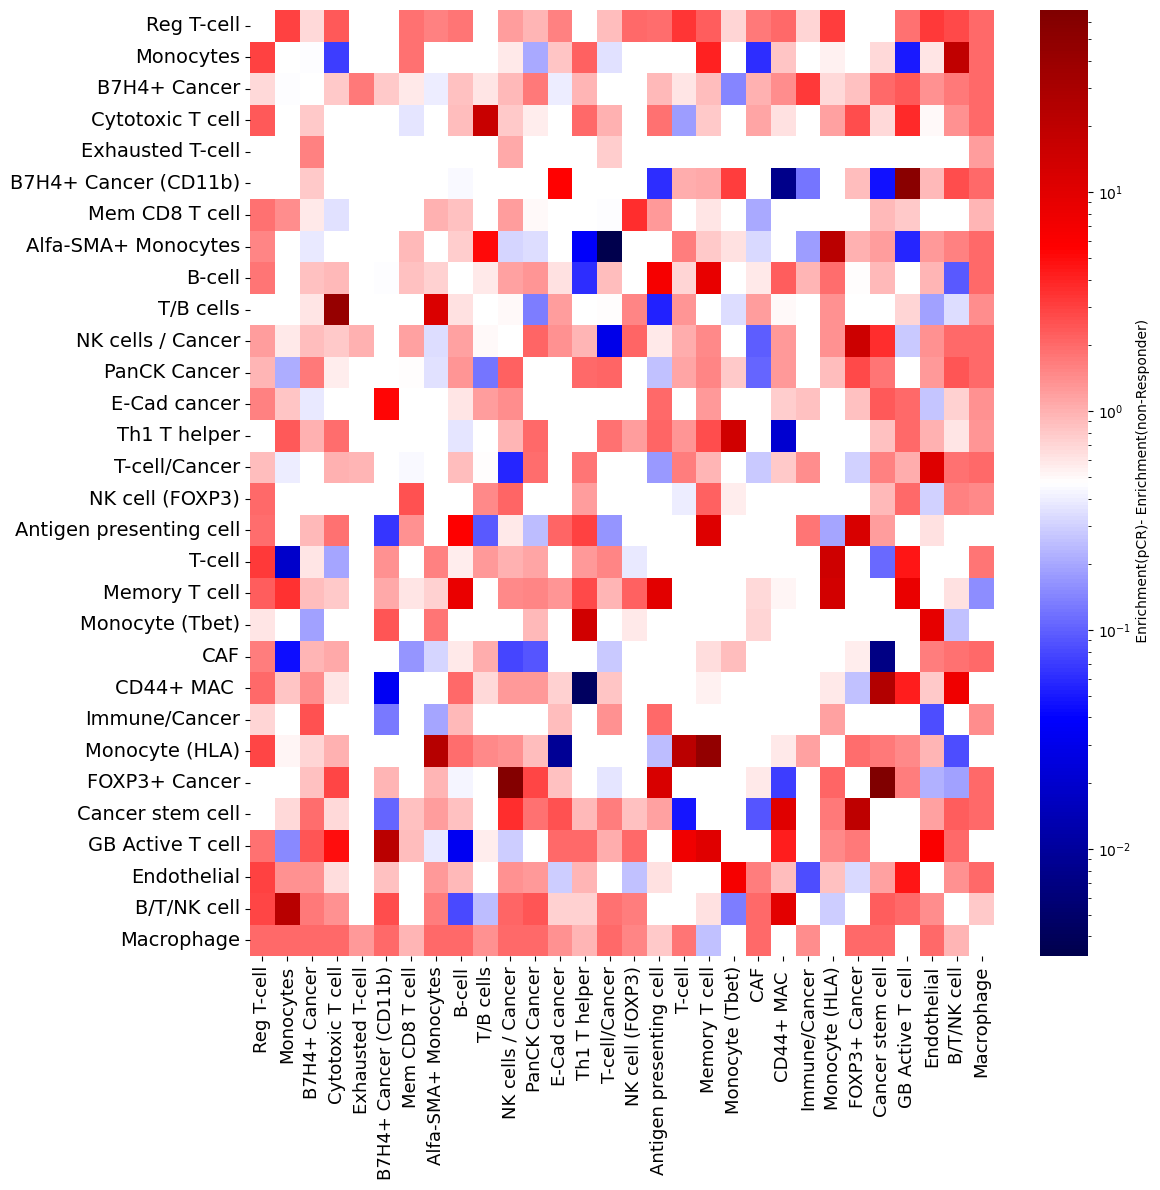

In [173]:
cutoff = 2
#axs[2].sharey(axs[1])
#axs[0].get_shared_y_axes().join(axs[1],axs[2])
def heatmap_mean_response(X,y,description):
    aux = X[y == 'Non-Responder']
    #mean_nR = pd.DataFrame(np.nanmean(aux,axis = 0)/np.nanstd(aux,axis = 0),index = labels_list2,columns=labels_list2)
    mean_nR = pd.DataFrame(np.nanmean(aux,axis = 0),index = labels_list2,columns=labels_list2)
    np.fill_diagonal(mean_nR.values,0)
    aux = X[y == 'pCR']
    mean_pCr = pd.DataFrame(np.nanmean(aux,axis = 0),index = labels_list2,columns=labels_list2).fillna(-cutoff)
    np.fill_diagonal(mean_pCr.values,0)
    plt.figure(figsize = (8,8))
    plt.title(description+' non responder')
    if description.find('enrichment')>0:
        mean_nR.fillna(-cutoff,inplace = True)
        mean_pCr.fillna(-cutoff,inplace = True)

        vmax = np.nanmax(mean_nR.abs().to_numpy())
        vmin = -vmax
        cmap='seismic'
    else:
        mean_nR.fillna(0,inplace = True)
        mean_pCr.fillna(0,inplace = True)

        vmax = np.nanmax(mean_nR.to_numpy())
        vmin = np.nanmin(mean_nR.to_numpy())
        cmap=None
    print(vmin, vmax)
#    sns.heatmap(mean_nR,cmap = cmap,xticklabels=True,yticklabels=True,vmin = vmin,vmax = vmax,cbar = True,cbar_kws={'label':'z-score'})
    sns.heatmap(mean_nR,cmap = cmap,xticklabels=True,yticklabels=True,vmin = -6.294031109385479,vmax = 6.294031109385479,cbar = True,cbar_kws={'label':'z-score'})    
    _ = plt.xticks(fontsize = 14,ha='center')
    _ = plt.yticks(fontsize = 14)
    plt.figure(figsize = (8,8))
    plt.title(description+' pCR')
    if description.find('enrichment')>0:

        vmax = np.nanmax(mean_pCr.abs().to_numpy())
        vmin = -vmax
    else:
        vmax = np.nanmax(mean_pCr.to_numpy())
        vmin = np.nanmin(mean_pCr.to_numpy())
    print(vmin, vmax)

    sns.heatmap(mean_pCr,cmap=cmap,xticklabels=True,yticklabels=True,cbar =True,vmin = vmin,vmax = vmax,cbar_kws={'label':'z-score'})
    _ = plt.xticks(fontsize = 14,ha='center')
    _ = plt.yticks(fontsize = 14)
    plt.figure(figsize = (12,12))
    diff = (mean_pCr-mean_nR)/(mean_pCr+mean_nR)*2
    vmax = np.nanmax(diff.abs().to_numpy())
    vmin = -vmax
    sns.heatmap(diff,cmap=cmap,xticklabels=True,yticklabels=True,vmin=vmin,vmax = vmax,cbar = True,norm = LogNorm(),cbar_kws={'label':' Enrichment(pCR)- Enrichment(non-Responder)'})
    _ = plt.xticks(fontsize = 13,ha='center')
    _ = plt.yticks(fontsize = 14)
    plt.tight_layout()
    return mean_nR,mean_pCr 
mean_nR_enr,mean_pCr_enr  = heatmap_mean_response(X_enrichment,y,'Contact enrichment')
#plt.savefig('../figures/spatial/neigh_diff_response.png')

In [177]:
%matplotlib inline

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/giuseppe/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_329925/1993186922.py", line 3, in <module>
    (mean_pCr_enr-mean_nR_enr)[key0].sort_values().plot(kind = 'bar')
  File "/home/giuseppe/anaconda3/lib/python3.9/site-packages/pandas/plotting/_core.py", line 920, in __call__
  File "/home/giuseppe/anaconda3/lib/python3.9/site-packages/pandas/plotting/_core.py", line 1886, in _get_plot_backend
    if hasattr(eps, "select"):
  File "/home/giuseppe/anaconda3/lib/python3.9/site-packages/pandas/plotting/_core.py", line 1817, in _load_backend
    >>> ax = df.plot.hexbin(x='x', y='y', gridsize=20)
ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/giuse

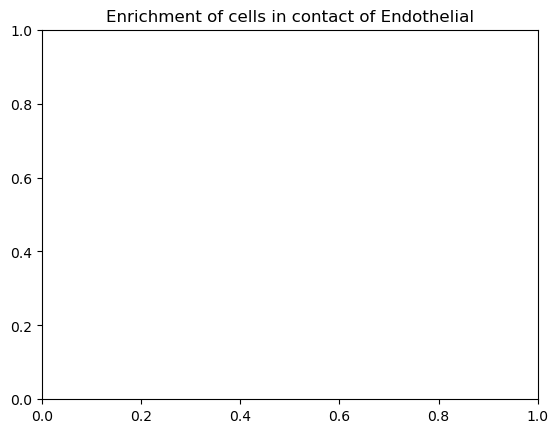

In [180]:
key0 = 'Endothelial'
plt.title('Enrichment of cells in contact of '+key0)
(mean_pCr_enr-mean_nR_enr)[key0].sort_values().plot(kind = 'bar')
_ = plt.xticks(rotation=90,fontsize = 14,ha='right')
plt.ylabel('Enriched in pCR vs non responders')
'Contact enrichment'.find('enrichmens')

0.0 0.007995373241047042
0.0 0.008599416802267102


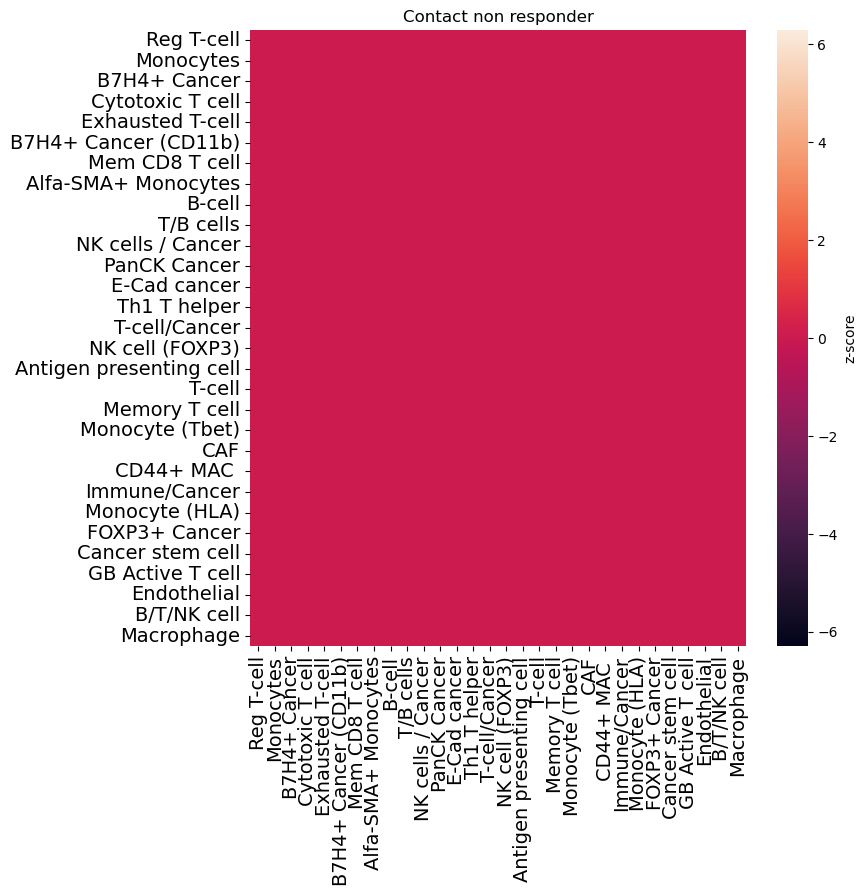

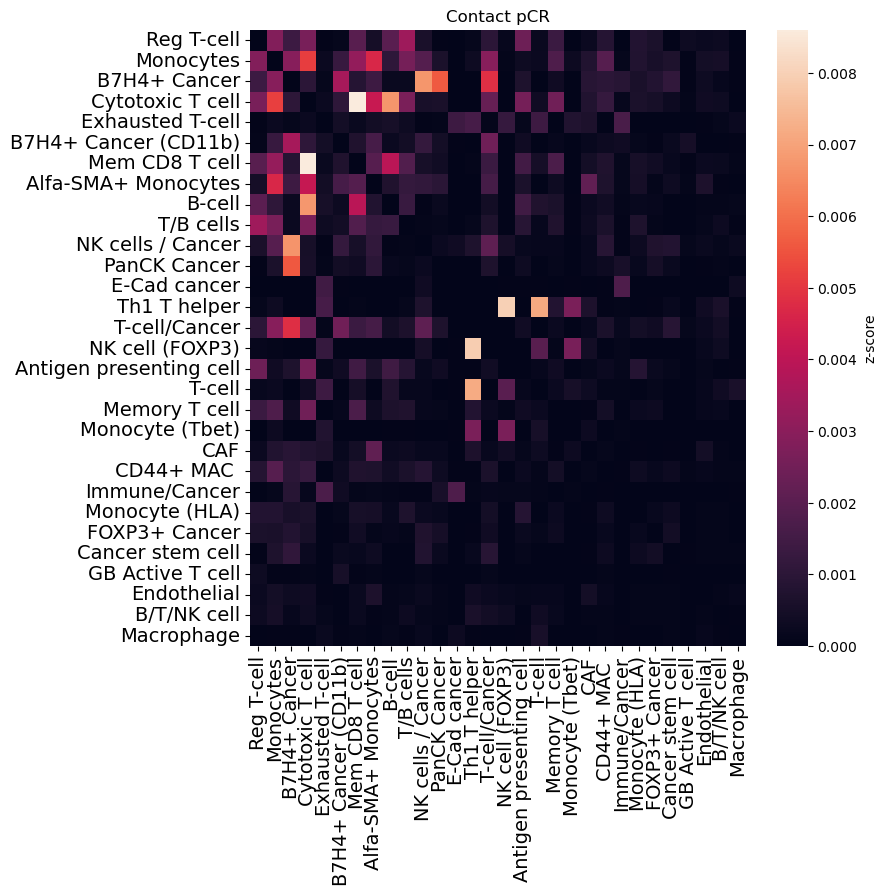

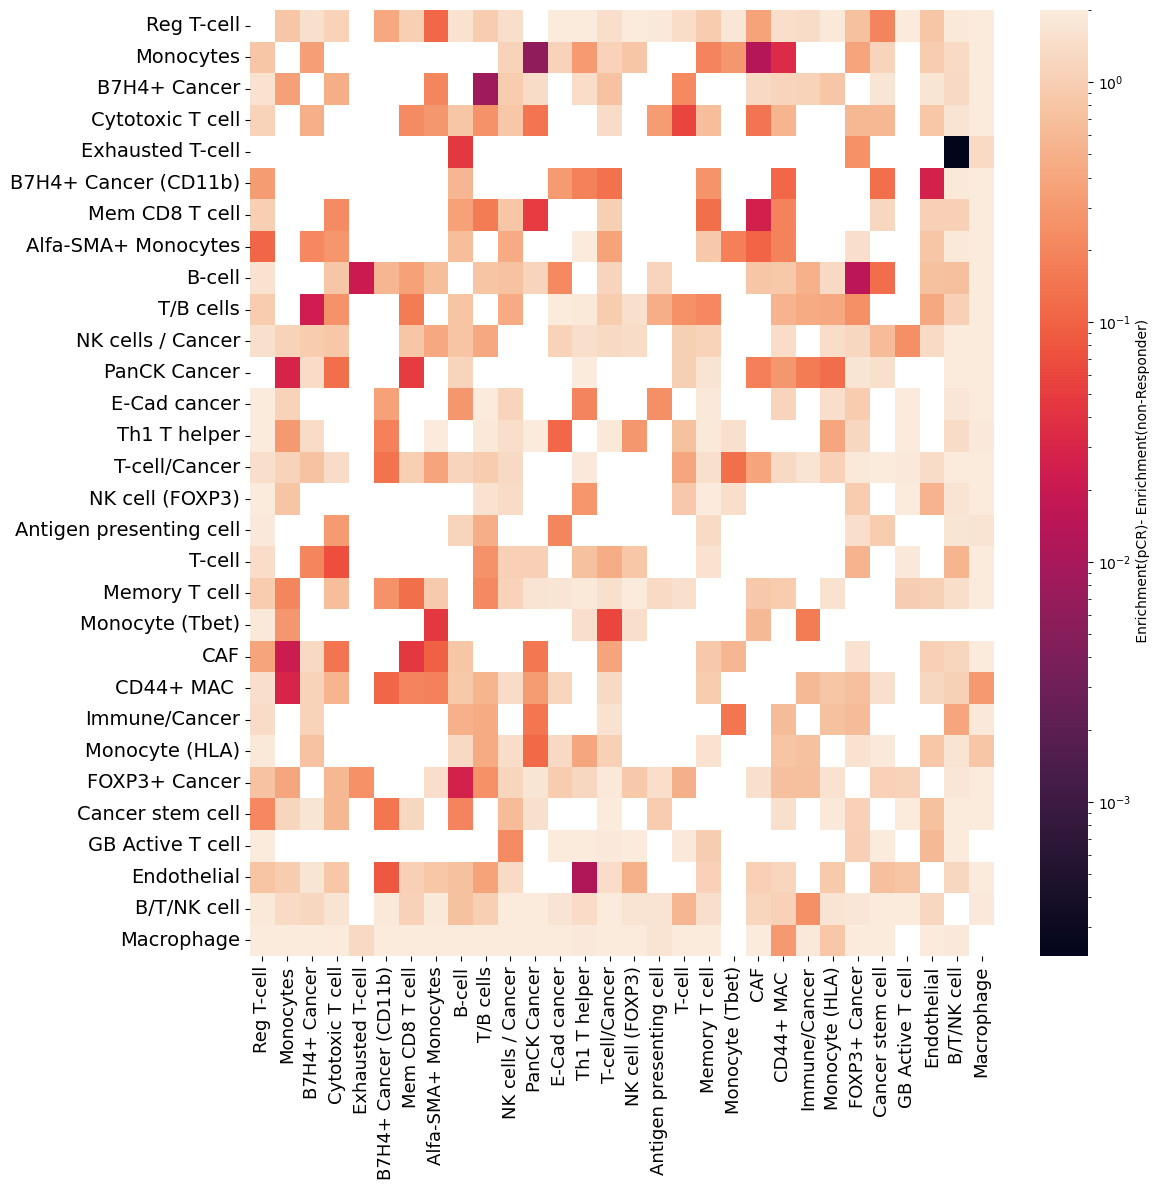

In [181]:
mean_nR_cont,mean_pCr_cont  = heatmap_mean_response(X_contact,y,'Contact')
mean_nR_cont.fillna(0,inplace=True)#for the contact, nan corresponds to no link
mean_pCr_cont.fillna(0,inplace=True)


<Axes: >

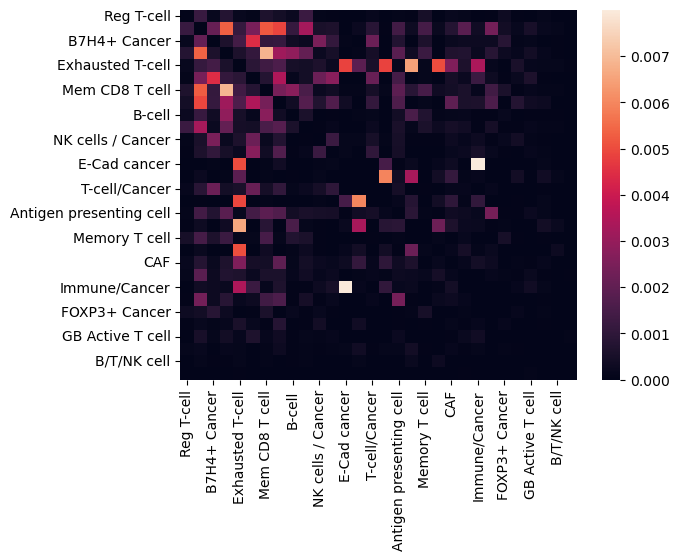

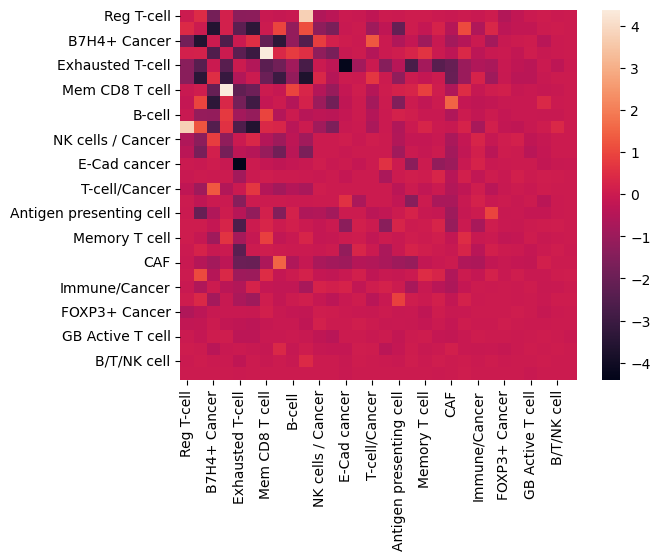

In [182]:
sns.heatmap(mean_nR_cont)
plt.figure()
sns.heatmap(mean_nR_enr.fillna(-0.5))

In [ ]:
key0 = 'Endothelial'
plt.title('Contact of cells in contact of '+key0)
(mean_pCr_cont-mean_nR_cont)[key0].sort_values().plot(kind = 'bar')
_ = plt.xticks(rotation=90,fontsize = 14,ha='right')
plt.ylabel('Contact in pCR minus non responders')
'Contact enrichment'.find('enrichmens')
plt.figure()
key0 = 'Endothelial'

plt.title('Contact of cells in contact of '+key0)
(mean_pCr_enr-mean_nR_enr)[key0].sort_values().plot(kind = 'bar')
_ = plt.xticks(rotation=90,fontsize = 14,ha='right')
plt.ylabel('Contact in pCR minus non responders')
'Contact enrichment'.find('enrichmens')

In [ ]:
aux = X_contact[y == 'Non-Responder']
#mean_nR = pd.DataFrame(np.nanmean(aux,axis = 0)/np.nanstd(aux,axis = 0),index = labels_list2,columns=labels_list2)#.fillna(-cutoff)
a = aux.reshape(-1)
plt.hist(a[a>0])

We now train a calissifier that, for each fov, it computes the contanct matrix enrichment, and uses it to predict response.The features that have more weight in the decision are postulated to have a biological importance

In [166]:
from sklearnex import patch_sklearn
from sklearn.linear_model import LogisticRegression
#from cuml.linear_model import LogisticRegression cuml does not work for multiclass regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV,cross_val_score

In [167]:
max_abs_scaler = preprocessing.MaxAbsScaler()
scaler = preprocessing.StandardScaler(with_mean = False)
le = LabelEncoder()
#pca = PCA(n_components=20)
y_num = le.fit_transform(y)

clip_value = 3
X_num = np.array([((x+x.T)/2)[np.triu_indices(len(x),k = 1)] for x in X_enrichment])
X_num[np.isnan(X_num)] = 0# I don't know why there are nan, as this contains off diagonal terms.

X_num = scaler.fit_transform(X_num)
X_num = np.clip(X_num,-clip_value,clip_value)
#X_num = pca.fit_transform(X_num)
X_train, X_test, y_train, y_test = train_test_split(X_num, y_num, test_size=0.33, random_state=42)
#X_test = np.clip(X_test,-clip_value,clip_value)#scaler.fit_transform(X_test)
#X_train = np.clip(X_train,-clip_value,clip_value)#scaler.fit_transform(X_train)

le.inverse_transform([0,1])

array(['Non-Responder', 'pCR'], dtype='<U13')

In [168]:
C_s_2_inspect = list(map(lambda x:x[0]*x[1], itertools.product([1e-4,1e-3,1e-2,1e-1,1,10],[1,2,5,7])))
tuned_parameters = [
    { 'class_weight':['balanced'],"C": C_s_2_inspect},
]

grid_search = GridSearchCV(
    LogisticRegression(), tuned_parameters,scoring='accuracy'
)
grid_search.fit(X_num, y_num)
clf = grid_search.best_estimator_
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.013389,0.008774,0.001258,0.000141,0.0001,balanced,"{'C': 0.0001, 'class_weight': 'balanced'}",0.632184,0.655172,0.651163,0.732558,0.674419,0.669099,0.034449,24
1,0.007553,0.001998,0.001112,0.000237,0.0002,balanced,"{'C': 0.0002, 'class_weight': 'balanced'}",0.643678,0.655172,0.651163,0.732558,0.697674,0.676049,0.033953,22
2,0.004367,0.000076,0.000814,0.000008,0.0005,balanced,"{'C': 0.0005, 'class_weight': 'balanced'}",0.632184,0.666667,0.651163,0.732558,0.697674,0.676049,0.035475,22
3,0.004379,0.000124,0.000812,0.000006,0.0007,balanced,"{'C': 0.0007, 'class_weight': 'balanced'}",0.643678,0.666667,0.651163,0.744186,0.720930,0.685325,0.039955,21
4,0.004435,0.000107,0.000822,0.000016,0.001,balanced,"{'C': 0.001, 'class_weight': 'balanced'}",0.643678,0.655172,0.674419,0.744186,0.720930,0.687677,0.038645,20
5,0.004779,0.000352,0.000982,0.000305,0.002,balanced,"{'C': 0.002, 'class_weight': 'balanced'}",0.666667,0.678161,0.697674,0.767442,0.744186,0.710826,0.038751,19
6,0.004649,0.000106,0.000817,0.000013,0.005,balanced,"{'C': 0.005, 'class_weight': 'balanced'}",0.701149,0.724138,0.755814,0.848837,0.779070,0.761802,0.051003,18
7,0.004839,0.000128,0.000822,0.000013,0.007,balanced,"{'C': 0.007, 'class_weight': 'balanced'}",0.724138,0.747126,0.755814,0.837209,0.779070,0.768671,0.038518,17
8,0.005334,0.000135,0.000818,0.000008,0.01,balanced,"{'C': 0.01, 'class_weight': 'balanced'}",0.724138,0.793103,0.755814,0.837209,0.767442,0.775541,0.037970,16
9,0.005902,0.000275,0.000823,0.000003,0.02,balanced,"{'C': 0.02, 'class_weight': 'balanced'}",0.735632,0.816092,0.790698,0.860465,0.813953,0.803368,0.040701,12


<Axes: >

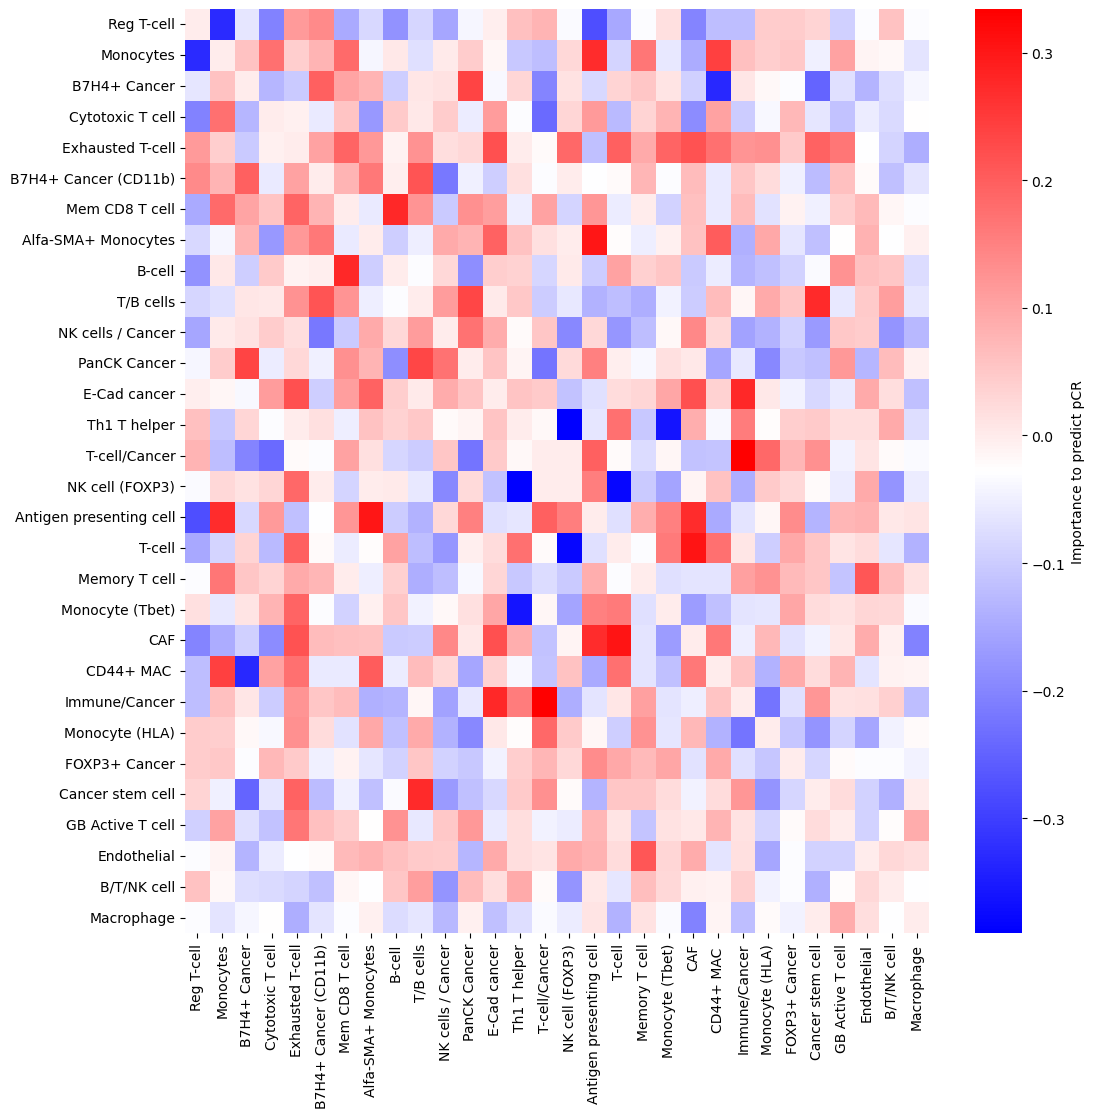

In [169]:
weight_importance  = np.zeros((len(labels_list2),len(labels_list2)))
weight_importance[np.triu_indices(len(labels_list2),k = 1)] = np.squeeze(clf.coef_)#fill the values of upper triangular
weight_importance[np.triu_indices(len(labels_list2),k = 1)[::-1]] = np.squeeze(clf.coef_)#fill the values of the lower triangular
weight_importance = pd.DataFrame(weight_importance,columns=labels_list2,index=labels_list2)
plt.figure(figsize = (12,12))
sns.heatmap(weight_importance,cmap='bwr',cbar_kws={'label':'Importance to predict pCR'})

In [170]:
top_features = np.squeeze(np.argsort(np.abs(clf.coef_)))[::-1]#features sorted by their importance in logistic regression 

a = list(zip(*labels_list[np.array(np.triu_indices(len(labels_list),k = 1))[:,top_features]],np.squeeze(clf.coef_)[top_features]))
interpret_lr = pd.DataFrame(a,columns = ['from','top','weight']).iloc[:20]
#positive weights means that it help response
interpret_lr['prediction_towards'] = interpret_lr.weight.apply(lambda x:'pCR' if x>0 else 'Non responder')
#interpret_lr.to_latex()
interpret_lr

,from,top,weight,prediction_towards
0,Memory T cell,Cancer stem cell,-0.389837,Non responder
1,B/T/NK cell,Vim+ Cancer / NK,-0.379065,Non responder
2,Memory T cell,E-Cad cancer,-0.358991,Non responder
3,Monocyte (HLA),FOXP3+ Cancer,0.334063,pCR
4,Th1 T helper,Cancer stem cell,-0.332292,Non responder
5,Exhausted T-cell,Immune/Cancer,-0.329188,Non responder
6,CD44+ MAC,T-cell/Cancer,0.305163,pCR
7,Macrophage,B7H4+ Cancer (CD11b),0.302190,pCR
8,Exhausted T-cell,B7H4+ Cancer,-0.278526,Non responder
9,Monocytes,B-cell,0.276132,pCR


/tmp/ipykernel_329925/558171887.py:56: RuntimeWarning: invalid value encountered in divide
  mean_all = pd.DataFrame(np.nanmean(X_contact,axis = 0)/np.nanstd(X_contact,axis  = 0),index = labels_list2,columns=labels_list2).fillna(0)


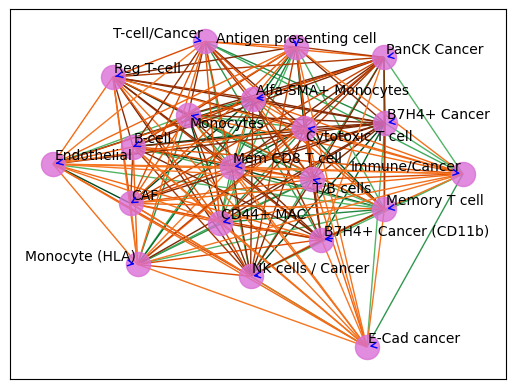

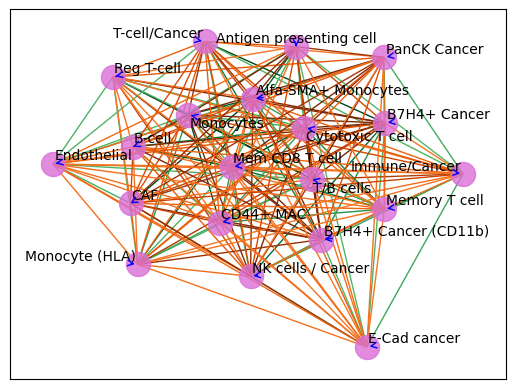

In [184]:
from adjustText import adjust_text
import networkx as nx


def create_corr_network(enrichment):
    G = nx.from_numpy_array(enrichment.values)
    G = nx.relabel_nodes(G,lambda x: list(enrichment.columns)[x])
    ...
    source, to, weight = zip(*G.edges(data = True))
    weight = np.array([w['weight']for w in weight])
    #cond = np.abs(weight)>min_correlation
    source, to, weight = np.stack((source, to, weight),axis = 1).T
    H = nx.Graph()
    

    H.add_weighted_edges_from(np.stack((source, to, weight),axis = 1),data = True)
    return H
def draw_network(G,positions = None):
    G.remove_edges_from(nx.selfloop_edges(G))
    edgelist = np.array(list(G.edges()))
    source, to, weight = zip(*G.edges(data = True))
    weight = np.array([w['weight']for w in weight]).astype(float)
    G.remove_nodes_from(list(nx.isolates(G)))
    #positions
    if positions is None:
        positions=nx.circular_layout(G)
    weight_colours = tuple([(1+abs(x))**2 for x in weight])
    nx.draw_networkx_nodes(G,pos = positions,node_color='#DA70D6',nodelist=G.nodes(),
                           #####the node size will be now based on its degree
                           alpha=0.8)
    
    cond = weight>0
    width = 1
    
    nx.draw_networkx_edges(G,edgelist= edgelist[cond],nodelist=G.nodes(),pos = positions,style='solid',
                          ###adds width=weights and edge_color = weights 
                          ###so that edges are based on the weight parameter 
                          ###edge_cmap is for the color scale based on the weight
                          ### edge_vmin and edge_vmax assign the min and max weights for the width
                          width= width, edge_color = np.array(weight_colours)[cond],edge_cmap  = plt.cm.Greens, 
                          edge_vmin = min(weight), edge_vmax=max(weight))
    cond = weight<0
    nx.draw_networkx_edges(G,edgelist= edgelist[cond],nodelist=G.nodes(),pos = positions,style='solid',
                          ###adds width=weights and edge_color = weights 
                          ###so that edges are based on the weight parameter 
                          ###edge_cmap is for the color scale based on the weight
                          ### edge_vmin and edge_vmax assign the min and max weights for the width
                          width=width, edge_color = np.array(weight_colours)[cond],edge_cmap  = plt.cm.Oranges, 
                          edge_vmin = min(weight), edge_vmax=max(weight))
    #Styling for labels
    #nx.draw_networkx_labels(H, positions, font_size=8, 
    #                            font_family='sans-serif')
    b = [plt.annotate(text,positions[text]*1,fontsize = 10) for text in list(G.nodes)]
    adjust_text(b, arrowprops=dict(arrowstyle='->', color='blue'))
    return positions
mean_all = pd.DataFrame(np.nanmean(X_contact,axis = 0)/np.nanstd(X_contact,axis  = 0),index = labels_list2,columns=labels_list2).fillna(0)
np.fill_diagonal(mean_all.values,0)

H = create_corr_network(mean_all)
H_pCr = create_corr_network(mean_pCr_enr)
H_nR = create_corr_network(mean_nR_enr)
#positions = draw_network(H,node = 'B7H4+ Cancer', min_weight = .3)
min_weight = .6
a,b,w_nr = zip(*H_nR.edges(data = True))
w_nr = np.array([d['weight'] for d in w_nr]).astype(float)
cond = (w_nr>min_weight)
celltypes_nR = set(np.array(a)[cond]).union(np.array(b)[cond])

a,b,w_pCr = zip(*H_pCr.edges(data = True))
w_pCr = np.array([d['weight'] for d in w_pCr]).astype(float)
cond = (w_pCr>min_weight)#*(w_pCr>min_weight)
celltypes_pCR = set(np.array(a)[cond]).union(np.array(b)[cond])

node = 'Endothelial'
#responder
positions=nx.spring_layout(nx.subgraph(H,celltypes_nR.union(celltypes_pCR)))
H_pCr = nx.subgraph(H_pCr,celltypes_nR.union(celltypes_pCR)).copy()
draw_network(H_pCr,positions=positions)
plt.figure()
#non responders
H_nR = nx.subgraph(H_nR,celltypes_nR.union(celltypes_pCR)).copy()
_ = draw_network(H_nR,positions=positions)

In [185]:
X_num = np.array([((x+x.T)/2)[np.triu_indices(len(x),k = 1)] for x in X_enrichment])
pair_labels =   list(zip(np.array(labels_list2)[np.triu_indices(len(labels_list2),k = 1)[0]],np.array(labels_list2)[np.triu_indices(len(labels_list2),k = 1)[1]]))
pair_labels = [':'.join(b)for b in pair_labels]
contact = sc.AnnData(pd.DataFrame(X_num,columns = pair_labels),obs = pd.DataFrame(y,columns = ['Response']))


/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [187]:
sc.tl.rank_genes_groups(contact, groupby='Response',  method='wilcoxon',groups=['Non-Responder'],reference='pCR', key_added = "wilcoxon")
wilcoxon_tb = sc.get.rank_genes_groups_df(contact, group='Non-Responder', key='wilcoxon').copy()
#s = wilcoxon_tb.loc[:,'pvals_adj']<0.05
s = (wilcoxon_tb['pvals_adj']<0.95) & (wilcoxon_tb['pvals_adj']>0.9)

#wilcoxon_tb


/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(


In [190]:
contact_tb
#pd.melt(contact_tb,id_vars=['Response'],value_vars = wilcoxon_tb[s].names)
a = pd.melt(contact_tb,id_vars=['Response'],value_vars = wilcoxon_tb[s].names,var_name='Cell:cell')
a

,Response,Cell:cell,value
0,pCR,B7H4+ Cancer (CD11b):FOXP3+ Cancer,0.0
1,pCR,B7H4+ Cancer (CD11b):FOXP3+ Cancer,0.0
2,pCR,B7H4+ Cancer (CD11b):FOXP3+ Cancer,0.0
3,pCR,B7H4+ Cancer (CD11b):FOXP3+ Cancer,0.0
4,Non-Responder,B7H4+ Cancer (CD11b):FOXP3+ Cancer,0.0
...,...,...,...
8203,Non-Responder,Cytotoxic T cell:FOXP3+ Cancer,0.0
8204,pCR,Cytotoxic T cell:FOXP3+ Cancer,0.0
8205,Non-Responder,Cytotoxic T cell:FOXP3+ Cancer,0.0
8206,Non-Responder,Cytotoxic T cell:FOXP3+ Cancer,0.0


In [47]:
wilcoxon_tb[s].set_index('names')

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Cytotoxic T cell:T-cell/Cancer,2.025951,-0.945052,0.042770,0.542358
T-cell/Cancer:CD44+ MAC,2.001547,-0.998767,0.045333,0.542358
PanCK Cancer:Endothelial,1.998448,-1.755493,0.045668,0.542358
Monocytes:T-cell/Cancer,1.994187,-0.296883,0.046132,0.542358
Cytotoxic T cell:CAF,1.981016,-1.322933,0.047589,0.544774
B7H4+ Cancer:NK cells / Cancer,-2.043771,-2.669149,0.040976,0.540141
Cytotoxic T cell:CD44+ MAC,-2.081346,-1.173769,0.037402,0.508437


/tmp/ipykernel_329925/3814248749.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  contact_tb[contact.var.index] = contact.X
/tmp/ipykernel_329925/3814248749.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  contact_tb[contact.var.index] = contact.X
/tmp/ipykernel_329925/3814248749.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented f

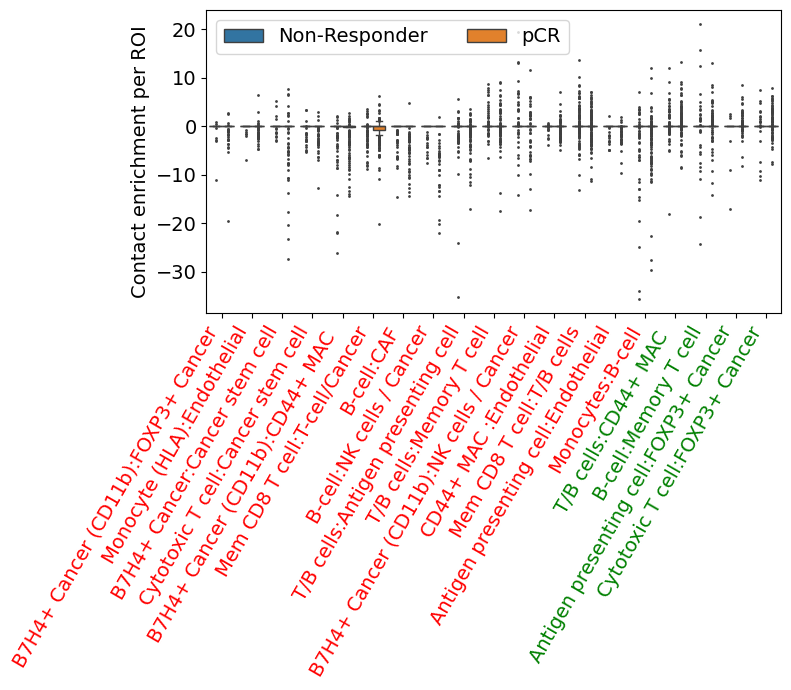

In [189]:
contact_tb  = contact.obs.copy()
contact_tb[contact.var.index] = contact.X
a = pd.melt(contact_tb,id_vars=['Response'],value_vars = wilcoxon_tb[s].names,var_name='Pixie')
plt.figure(figsize = (8,7))
boxplot = sns.boxplot(a,x = 'Pixie',y = 'value',hue = 'Response',fliersize = 1)
_ = plt.xticks(rotation=60,fontsize = 14,ha='right')
_ = plt.yticks(fontsize = 14)
boxplot.legend(fontsize=14,ncols = 2)
ax = plt.gca()
for cell_type in ax.xaxis.get_ticklabels():
    if wilcoxon_tb[s].set_index('names').loc[cell_type.get_text()].scores>0:
        cell_type.set_color('red')
    else:
        cell_type.set_color('green')
ax.set_xticklabels(ax.get_xticklabels(), rotation=60,ha = 'right')
plt.ylabel('Contact enrichment per ROI',fontsize = 14)
plt.xlabel('',fontsize = 0)
plt.tight_layout()
#plt.savefig('../../figures/spatial/diff_cell_enrichment.png')

In [811]:
def normalise_by_group(adata,group_key,quantile = 0.95,inplace = True,force_normalisation = False):
    '''Normalise cell marker by group_key'''
    if isinstance(adata, sc.AnnData):
        if np.all(adata.X<=1):
            logger.warning('data seem already normalised')
            if force_normalisation:
                logger.warning('Normalising anyway')
            else:
                logger.warning('Skipping normalisation. Select force_normalisation =True if you want to normalise anyway')
                return adata

    else:
        raise ValueError('Need adata object')

    #create a dictionary that maps adata.obs.index to indices of adata.X
    dic = {ind:i for i,ind in enumerate(adata.obs.index)}
    dic = np.vectorize(dic.__getitem__)
    out = np.zeros_like(adata.X)#vector where the normalised values are stored
    for _, index_labels in adata.obs.groupby('Patient').groups.items():
        data = adata.raw.X[dic(index_labels)]
        q = np.nanquantile(data,q = quantile,axis = 0)
        data = sklearn.preprocessing.StandardScaler().fit_transform(data)
        out[dic(index_labels)] = data
    
    if inplace:
        adata.X = out
        return adata
    else:
        return out

X = adata.raw.X[:,~adata.var.index.isin(['Carboplatin','DNA1','DNA2'])]
X = np.arcsinh(X)
a = sc.AnnData(X)
a.obs = adata.obs
a.var = adata[:,~adata.var.index.isin(['Carboplatin','DNA1','DNA2'])].var
a.raw = a
a.obsm = adata.obsm
normalise_by_group(a,group_key='Leap_ID',inplace=True,force_normalisation=True)
adata = a.copy()

In [812]:
store = {}    
cell_radius = 20
for ID in  set(adata.obs.acquisition_ID.drop_duplicates()):
    sub_adata = adata[adata.obs.acquisition_ID==ID].copy()#select one acquisition
    celltypes = sub_adata.obs.Pixie.value_counts()[sub_adata.obs.Pixie.value_counts()>50].index.values#take cell types that have at least 50 cells in the acquisition
    sq.gr.spatial_neighbors(sub_adata,coord_type='grid',n_neighs=6,radius = (0,cell_radius))
    A = sub_adata[:,sub_adata.var.index!='Carboplatin'].X
    store[ID]=A.T@sub_adata.obsp['spatial_connectivities']@A /len(sub_adata.obs)#similarity metric at the protein level of cells in contact
    #store is a  dictionary of matrices.


In [813]:
sub_adata.obsp['spatial_connectivities'],A.shape

(<3324x3324 sparse matrix of type '<class 'numpy.float64'>'
 	with 15233 stored elements in Compressed Sparse Row format>,
 (3324, 35))

In [814]:
[i for i,v in store.items() ]
'Leap087_4' in core.obs.acquisition_ID.to_list()
core_ids = set(core.obs.acquisition_ID)

<Axes: >

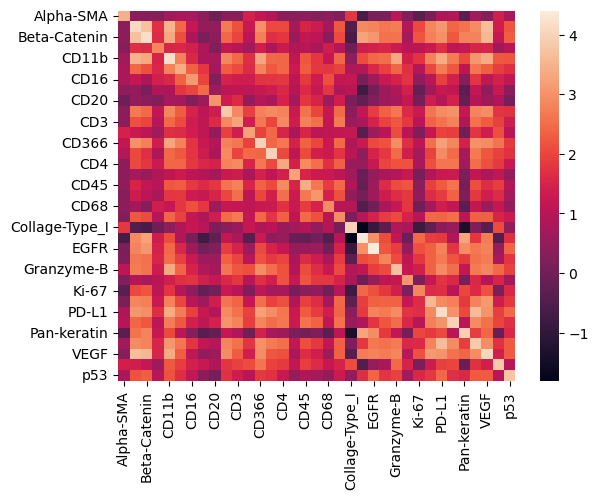

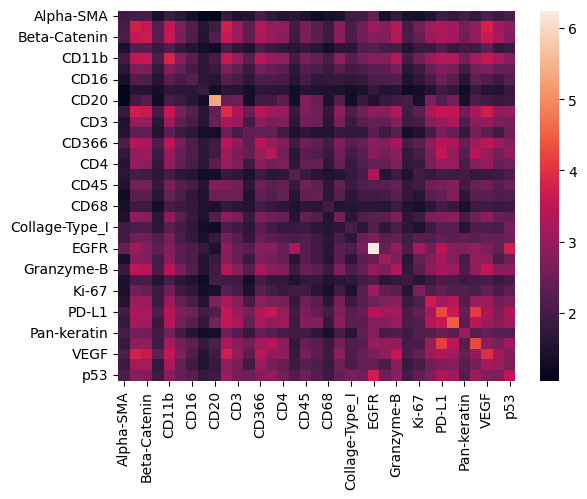

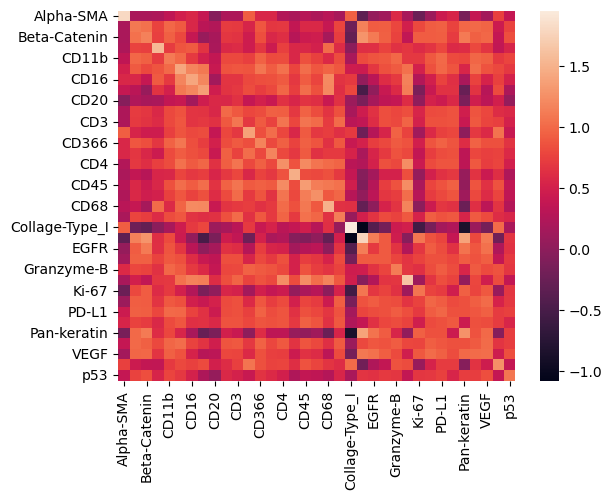

In [815]:
a = np.mean([v for i,v in store.items() if i in core_ids],axis = 0)
b = np.std([v for i,v in store.items() if i in core_ids],axis = 0)
indices = adata[:,adata.var.index!='Carboplatin'].var.index
sns.heatmap(pd.DataFrame(a,index = indices,columns = indices))
plt.figure()
sns.heatmap(pd.DataFrame(b,index = indices,columns=indices))
plt.figure()
sns.heatmap(pd.DataFrame(a/b,index = indices,columns=indices))

In [816]:
resp_ids = set(core[core.obs.Response=='pCR'].obs.acquisition_ID)
resp = np.mean([v for i,v in store.items() if i in resp_ids],axis = 0)
nR = np.mean([v for i,v in store.items() if i not in resp_ids],axis = 0)

<Axes: >

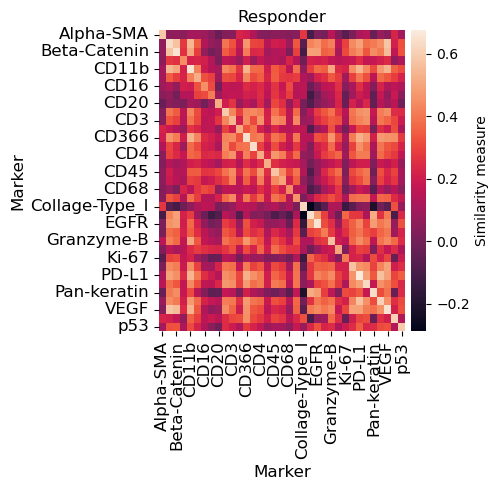

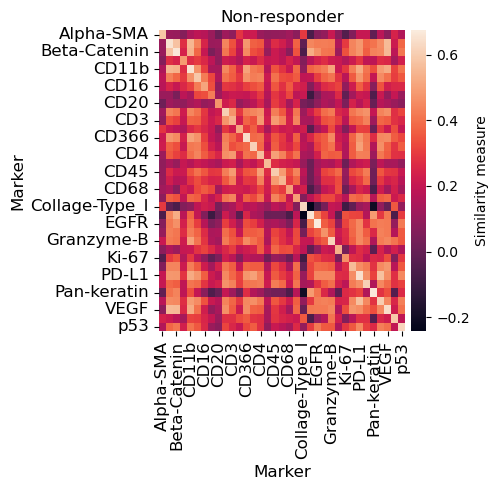

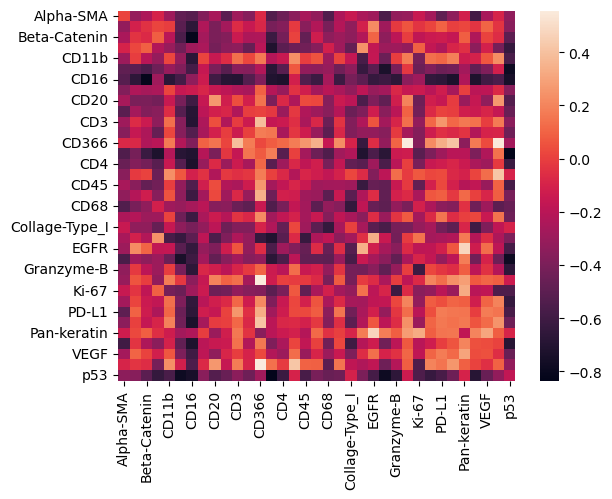

In [1017]:
plt.figure(figsize = (5,5))
b = sns.heatmap(pd.DataFrame(resp/6,index = indices,columns=indices),cbar_kws={'pad':0.02,'label':'Similarity measure'})
b.set_xticklabels(b.get_xmajorticklabels(), fontsize = 12)
b.set_yticklabels(b.get_ymajorticklabels(), fontsize = 12)

plt.title('Responder')
plt.xlabel('Marker', fontsize = 12)
plt.ylabel('Marker', fontsize = 12)

plt.tight_layout()
plt.savefig('../../figures/spatial/corr_contact_resp.png')
plt.figure(figsize = (5,5))
plt.title('Non-responder')
b = sns.heatmap(pd.DataFrame(nR/6,index = indices,columns=indices),cbar_kws={'pad':0.02,'label':'Similarity measure'})
b.set_xticklabels(b.get_xmajorticklabels(), fontsize = 12)
b.set_yticklabels(b.get_ymajorticklabels(), fontsize = 12)
plt.xlabel('Marker', fontsize = 12)
plt.ylabel('Marker', fontsize = 12)

plt.tight_layout()
plt.savefig('../../figures/spatial/corr_contact_nr.png')
plt.figure()
sns.heatmap(pd.DataFrame(resp,index = indices,columns=indices)-pd.DataFrame(nR,index = indices,columns=indices))

In [961]:
a = np.abs(resp-nR)[np.tril_indices_from(resp)]>0.5
a.sum()

78

In [962]:
ind =np.triu_indices_from(resp)
resp_all = np.array([v[ind] for i,v in store.items() if i in resp_ids])
nR_all = np.array([v[ind] for i,v in store.items() if i not in resp_ids])

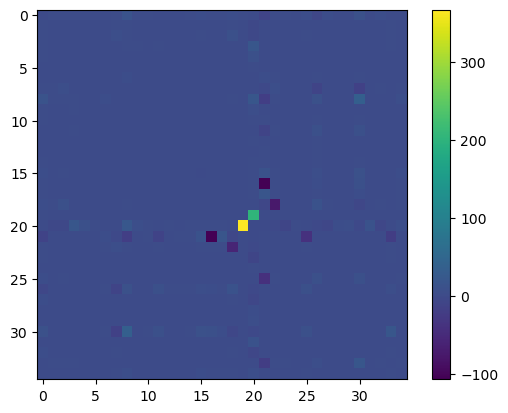

In [963]:
import random
from scipy.stats import variation 
plt.imshow(variation(random.sample(list(store.values()),100)))
plt.colorbar()

In [1015]:
markers_2_inspect = ['Beta-Catenin','p53','VEGF','PD-L2','PD-L1','PD-1']
np.isin(indices,markers_2_inspect)


array([False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True,  True,  True, False, False,  True, False,  True])

In [964]:
core_ids = set(core.obs.acquisition_ID)
#a = np.argsort(variation(list(store.values()))[np.triu_indices_from(resp)])[-20:]#select the variables with highest variation
ids,X = zip(*[[k,el[np.triu_indices_from(resp)][a]] for k,el in store.items()if k in core_ids] )
a = core.obs[['acquisition_ID','Response']].drop_duplicates()
a['Response'] =a.Response.map({'Non-Responder':0,'pCR':1})
dic = dict(a.values)
y = np.vectorize(dic.__getitem__)(ids)

In [973]:
import random
def train_test_split(X,y):
    patients = list(core.obs.Patient.unique())
    patients_train = random.sample(patients,int(len(patients)*0.7))
    X_train = []
    X_test = []
    y_train = []
    y_test = []
    a  = core.obs[['Patient','acquisition_ID']].drop_duplicates().set_index('acquisition_ID')
    for id,x,target in zip(ids,X,y):
        if a.loc[id].Patient in patients_train:
            X_train +=[x]
            y_train +=[target]
        else:
            X_test +=[x]
            y_test +=[target]
            
    X_train = np.array(X_train)
    X_test = np.array(X_test)
    y_train = np.array(y_train)
    y_test = np.array(y_test)
    return X_train,X_test,y_train,y_test

In [966]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score,  f1_score,precision_score,recall_score
def compute_scores_train(y_train, y_pred_train, y_test, y_pred_test,y_prob_train,y_prob_test):
	"""
	Computes various evaluation scores for both training and test sets.

	Args:
		y_train (list or numpy.ndarray): True labels for training set.
		y_pred_train (list or numpy.ndarray): Predicted labels for training set.
		y_test (list or numpy.ndarray): True labels for test set.
		y_pred_test (list or numpy.ndarray): Predicted labels for test set.

	Returns:
		metrics (dict): Dictionary containing evaluation metrics for both sets.
	"""
	accuracy_train = accuracy_score(y_train, y_pred_train)
	balanced_accuracy_train = balanced_accuracy_score(y_train, y_pred_train,adjusted=False)
	auc_train = roc_auc_score(y_train, y_prob_train)
	f1_train = f1_score(y_train, y_pred_train)

	accuracy_test = accuracy_score(y_test, y_pred_test)
	balanced_accuracy_test = balanced_accuracy_score(y_test, y_pred_test,adjusted=False)
	auc_test = roc_auc_score(y_test, y_prob_test)
	f1_test = f1_score(y_test, y_pred_test)
	metrics = {
			'Accuracy':{ 'Train': accuracy_train,'Test': accuracy_test},
			'Balanced_Accuracy':{'Train': balanced_accuracy_train,'Test': balanced_accuracy_test},
            'Precision': {'Train':precision_score(y_train,y_pred_train),'Test': precision_score(y_test,y_pred_test)},
            'Recall':{'Train': recall_score(y_train,y_pred_train),'Test': recall_score(y_test,y_pred_test)},
			'AUC':{ 'Train': auc_train,'Test': auc_test},
			'F1 Score':{ 'Train': f1_train,'Test': f1_test},
	}
	return metrics


from imblearn.over_sampling import SMOTE
sm = SMOTE(sampling_strategy = 1 ,k_neighbors = 5)  
#sm =  SMOTE(sampling_strategy = {1:300,0:300} ,k_neighbors = 20)  
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
Counter(y_train_res),Counter(y_train)
Counter(y_train_res)[0]

170

In [970]:
balance_ratio= Counter(y_train)[0]/Counter(y_train)[1]
boosting = XGBClassifier(n_estimators=10, max_depth=3, learning_rate=.001, objective='binary:logistic', device="cuda",min_split_loss = 50,reg_lambda = 1,sampling_method = 'gradient_based',subsample = .1,scale_pos_weight=balance_ratio)
boosting.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.001, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, min_split_loss=50, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=10,
              n_jobs=None, num_parallel_tree=None, ...)

In [971]:
a = compute_scores_train(y_train, boosting.predict(X_train), y_test, boosting.predict(X_test),y_prob_train=boosting.predict_proba(X_train)[:,1],y_prob_test=boosting.predict_proba(X_test)[:,1])
pd.DataFrame(a)

,Accuracy,Balanced_Accuracy,Precision,Recall,AUC,F1 Score
Train,0.688136,0.680706,0.729412,0.729412,0.739671,0.729412
Test,0.467153,0.467072,0.462687,0.455882,0.483163,0.459259


In [977]:
data = []
for _ in range(10):
    #sm = SMOTE(sampling_strategy = 1 ,k_neighbors = 5)  
    X_train,X_test,y_train,y_test = train_test_split(X,y)
    #X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    balance_ratio= Counter(y_train)[0]/Counter(y_train)[1]
    boosting = XGBClassifier(n_estimators=10, max_depth=3, learning_rate=.001, objective='binary:logistic', device="cuda",min_split_loss = 50,reg_lambda = 1,sampling_method = 'gradient_based',subsample = .1,scale_pos_weight=balance_ratio)
    boosting.fit(X_train,y_train)
    data+=[pd.DataFrame(compute_scores_train(y_train, boosting.predict(X_train), y_test, boosting.predict(X_test),y_prob_train=boosting.predict_proba(X_train)[:,1],y_prob_test=boosting.predict_proba(X_test)[:,1]))]

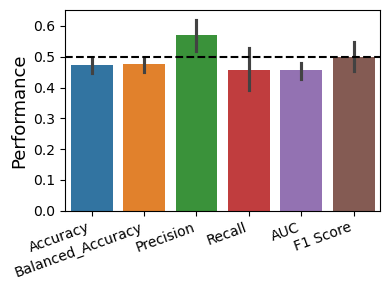

In [979]:
plt.figure(figsize= (4,3))
d = pd.concat(data).reset_index(names = 'experiment')
sns.barplot(d[d.experiment == 'Test'])
plt.xticks(rotation = 20,ha = 'right')
plt.axhline(0.5,c ='k',ls = '--')
plt.ylabel('Performance',fontsize = 13)
plt.tight_layout()
#plt.savefig('../../figures/prediction/performance_cell_predictor_train.png')

In [972]:
(boosting.predict(X_test) == y_test)[y_test == 1].mean(),(boosting.predict(X_test) == y_test)[y_test == 0].mean()

(0.45588235294117646, 0.4782608695652174)

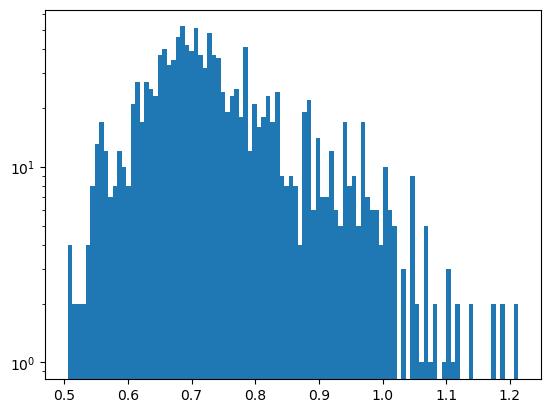

Init signature:
SMOTE(
    *,
    sampling_strategy='auto',
    random_state=None,
    k_neighbors=5,
    n_jobs=None,
)
Docstring:     
Class to perform over-sampling using SMOTE.

This object is an implementation of SMOTE - Synthetic Minority
Over-sampling Technique as presented in [1]_.

Read more in the :ref:`User Guide <smote_adasyn>`.

Parameters
----------
sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
      number of samples in the minority class after resampling and
      :math:`N_{M}` is the number of samples in the majority class.

        .. warning::
           ``float`` is only available for **binary** classification

In [626]:
plt.hist(variation(random.sample(list(store.values()),100)).reshape(-1),100)
plt.semilogy()


In [631]:
sm = SMOTE(sampling_strategy = {1:1000,0:1000} ,k_neighbors = 5)  
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
Counter(y_train_res),Counter(y_train)

(Counter({1: 1000, 0: 1000}), Counter({0: 150, 1: 142}))

In [629]:
SMOTE?

Init signature:
SMOTE(
    *,
    sampling_strategy='auto',
    random_state=None,
    k_neighbors=5,
    n_jobs=None,
)
Docstring:     
Class to perform over-sampling using SMOTE.

This object is an implementation of SMOTE - Synthetic Minority
Over-sampling Technique as presented in [1]_.

Read more in the :ref:`User Guide <smote_adasyn>`.

Parameters
----------
sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
      number of samples in the minority class after resampling and
      :math:`N_{M}` is the number of samples in the majority class.

        .. warning::
           ``float`` is only available for **binary** classification

(array([6.9220688e+07, 3.1179878e+07, 2.0225062e+07, 1.0266513e+07,
        3.4575110e+06, 7.2423200e+05, 8.3618000e+04, 3.1660000e+03,
        1.0000000e+01, 2.0000000e+00]),
 array([0.        , 0.93182217, 1.86364433, 2.7954665 , 3.72728866,
        4.65911083, 5.59093299, 6.52275516, 7.45457732, 8.38639949,
        9.31822165]),
 <BarContainer object of 10 artists>)

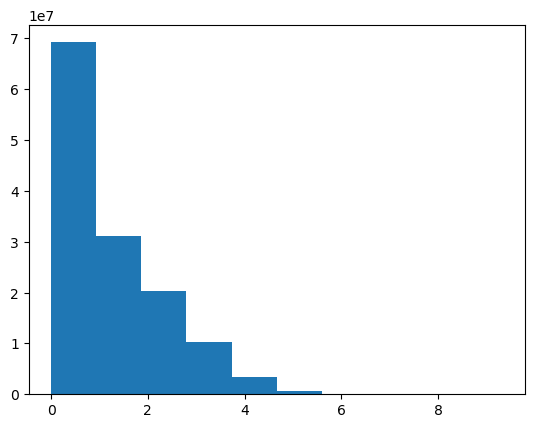

In [801]:
plt.hist(np.arcsinh(adata.raw.X).reshape(-1))

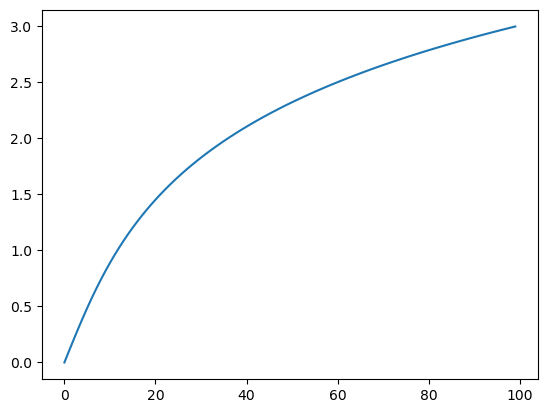

In [798]:
plt.plot(np.arcsinh(np.linspace(0,10,100)))